# 🚀 Đồ Án NLP: Trích Xuất Sự Kiện Quan Trọng từ Tin Tức Tài Chính Đa Ngôn Ngữ (Anh-Việt)

---
## Quy trình 6 bước:
1. Thu thập dữ liệu (FinancialPhraseBank + Crawl CafeF)
2. EDA – Phân tích dữ liệu khám phá
3. Tiền xử lý & BIO Tagging
4. Xây dựng mô hình (XLM-RoBERTa + NER + Relation Extraction)
5. Đánh giá (Precision, Recall, F1, Confusion Matrix)
6. Demo App (Flask trên Colab + ngrok)


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
path = "/content/drive/MyDrive/Do_an_TH_NLP"

if os.path.exists(path):
    os.chdir(path)
    print(f"Đã trỏ về {os.getcwd()}")
else:
    print(f"Không tìm thấy thư mục {path}")

Đã trỏ về /content/drive/MyDrive/Do_an_TH_NLP


## ⚙️ Cài đặt thư viện

In [ ]:
# ⚡ QUAN TRỌNG: Sau khi cell này chạy xong, vào Runtime → Restart session
# rồi chạy lại từ cell này trở đi (KHÔNG cần chạy lại cell cài đặt)
%%capture
# transformers 4.46.x: ổn định, hỗ trợ Python 3.12, có EncoderDecoderCache
!pip install 'transformers==4.46.3' datasets seqeval pyngrok flask flask-cors
!pip install torch requests beautifulsoup4
!pip install underthesea langdetect plotly


In [ ]:
print('✅ Cài đặt thư viện hoàn tất!')

✅ Cài đặt thư viện hoàn tất!


In [ ]:
# ⚠️  Nếu thấy NameError/ImportError, hãy: Runtime → Restart session → Run All
import os, re, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
import seaborn as sns
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
warnings.filterwarnings('ignore')

import torch
from torch.utils.data import Dataset

# ── Transformers imports (yêu cầu transformers>=4.44 cho Python 3.12) ──
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'🖥️  Thiết bị : {DEVICE}')
print(f'🔥 CUDA     : {torch.cuda.is_available()}')

# Kiểm tra version transformers
import transformers
print(f'🤗 Transformers: {transformers.__version__}')
assert transformers.__version__ >= '4.44', \
    f'Cần transformers>=4.44, hiện tại: {transformers.__version__}. Chạy lại cell cài đặt!'
print('✅ Tất cả thư viện đã sẵn sàng!')


🖥️  Thiết bị : cuda
🔥 CUDA     : True
🤗 Transformers: 4.46.3
✅ Tất cả thư viện đã sẵn sàng!


---
## 📥 BƯỚC 1: THU THẬP DỮ LIỆU

In [ ]:
# =========================================================
# 1A. Tải & Đọc FinancialPhraseBank từ file archive.zip
# =========================================================
import zipfile

# -- Tự động upload trên Google Colab --
def get_zip_path():
    """Trả về đường dẫn archive.zip; upload nếu chạy trên Colab."""
    candidates = ['archive.zip', '/content/archive.zip',
                  '/content/drive/MyDrive/archive.zip']
    for p in candidates:
        if os.path.exists(p):
            print(f'✅ Tìm thấy file: {p}')
            return p
    # Thử upload nếu đang chạy trên Colab
    try:
        from google.colab import files
        print('📂 Vui lòng upload file archive.zip...')
        uploaded = files.upload()
        if uploaded:
            fname = list(uploaded.keys())[0]
            print(f'✅ Đã upload: {fname}')
            return fname
    except ImportError:
        pass
    print('⚠️  Không tìm thấy archive.zip – sẽ dùng dữ liệu mẫu.')
    return None

ZIP_PATH = get_zip_path()

def load_financial_phrasebank(zip_path,
                               filename='FinancialPhraseBank/Sentences_50Agree.txt'):
    """Đọc FinancialPhraseBank từ file zip."""
    sentences, labels = [], []
    if zip_path and os.path.exists(zip_path):
        try:
            with zipfile.ZipFile(zip_path, 'r') as z:
                with z.open(filename) as f:
                    content = f.read().decode('latin-1')
            for line in content.strip().split('\n'):
                line = line.strip()
                if '@' in line:
                    parts = line.rsplit('@', 1)
                    if len(parts) == 2:
                        sentences.append(parts[0].strip())
                        labels.append(parts[1].strip())
            print(f'✅ Đọc {len(sentences)} câu từ {filename}')
            return sentences, labels
        except Exception as e:
            print(f'⚠️  Lỗi đọc file: {e}')
    # Dữ liệu mẫu dự phòng
    print('⚠️  Sử dụng dữ liệu mẫu dự phòng...')
    sample = [
        ("Bitcoin surged 15% after BlackRock ETF approval.",        "positive"),
        ("Binance faces regulatory crackdown in multiple countries.", "negative"),
        ("Ethereum network upgrade scheduled for next month.",        "neutral"),
        ("Company reports record profits for Q3 2024.",              "positive"),
        ("CEO resigns amid fraud allegations.",                      "negative"),
        ("Operating profit rose to EUR 13.1 mn from EUR 8.7 mn.",   "positive"),
        ("The firm acquired its rival for USD 500 million.",         "positive"),
        ("Net sales declined 10% in the third quarter.",             "negative"),
        ("The board approved a dividend increase of 5%.",            "positive"),
        ("Market volatility caused shares to fall 8%.",              "negative"),
    ] * 200
    sentences, labels = zip(*sample)
    return list(sentences), list(labels)

en_sentences, en_labels = load_financial_phrasebank(ZIP_PATH)
df_en = pd.DataFrame({'text': en_sentences, 'label': en_labels, 'lang': 'en'})
print(df_en.head(3))
print('\nPhân phối nhãn:')
print(df_en['label'].value_counts())


✅ Tìm thấy file: archive.zip
✅ Đọc 4846 câu từ FinancialPhraseBank/Sentences_50Agree.txt
                                                text     label lang
0  According to Gran , the company has no plans t...   neutral   en
1  Technopolis plans to develop in stages an area...   neutral   en
2  The international electronic industry company ...  negative   en

Phân phối nhãn:
label
neutral     2879
positive    1363
negative     604
Name: count, dtype: int64


In [ ]:
# =========================================================
# 1B. Script cào tin tức tài chính từ CafeF (Tiếng Việt)
# =========================================================
import requests
from bs4 import BeautifulSoup
import time

def scrape_cafef_news(max_articles=30, timeout=10):
    """Cào tin tức tài chính từ CafeF.vn."""
    articles = []
    base_urls = [
        'https://cafef.vn/thi-truong-chung-khoan.chn',
        'https://cafef.vn/tai-chinh-ngan-hang.chn',
        'https://cafef.vn/bat-dong-san.chn',
    ]
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36',
        'Accept-Language': 'vi-VN,vi;q=0.9,en;q=0.8'
    }
    for base_url in base_urls:
        if len(articles) >= max_articles:
            break
        try:
            resp = requests.get(base_url, headers=headers, timeout=timeout)
            soup = BeautifulSoup(resp.text, 'html.parser')
            links = []
            for a in soup.find_all('a', href=True):
                href = a['href']
                if href.endswith('.chn') and '//' not in href:
                    links.append('https://cafef.vn' + href)
                elif 'cafef.vn' in href and href.endswith('.chn'):
                    links.append(href)
            links = list(set(links))[:10]
            for link in links:
                if len(articles) >= max_articles:
                    break
                try:
                    r = requests.get(link, headers=headers, timeout=timeout)
                    s = BeautifulSoup(r.text, 'html.parser')
                    title_tag = s.find('h1')
                    title = title_tag.get_text(strip=True) if title_tag else ''
                    sapo = s.find('h2', class_='sapo') or s.find('p', class_='sapo')
                    sapo_text = sapo.get_text(strip=True) if sapo else ''
                    content_div = s.find('div', class_='detail-content') or s.find('article')
                    paragraphs = []
                    if content_div:
                        for p in content_div.find_all('p')[:5]:
                            paragraphs.append(p.get_text(strip=True))
                    full_text = ' '.join([title, sapo_text] + paragraphs).strip()
                    if len(full_text) > 50:
                        articles.append({'url': link, 'title': title,
                                         'text': full_text, 'lang': 'vi'})
                    time.sleep(0.5)
                except Exception:
                    continue
        except Exception as e:
            print(f'  Lỗi khi cào {base_url}: {e}')
    print(f'✅ Cào được {len(articles)} bài viết từ CafeF')
    return articles

print('🕷️  Đang cào dữ liệu từ CafeF.vn...')
vi_articles = scrape_cafef_news(max_articles=30)

VI_SAMPLE = [
    "VN-Index tăng mạnh 15 điểm trong phiên giao dịch chiều nay nhờ lực đỡ từ nhóm cổ phiếu ngân hàng.",
    "Ngân hàng Nhà nước công bố giảm lãi suất điều hành xuống 4.5% nhằm hỗ trợ doanh nghiệp.",
    "Bitcoin lập đỉnh mới 80.000 USD, các sàn giao dịch tiền mã hóa Việt Nam ghi nhận lượng giao dịch tăng vọt.",
    "Tập đoàn Vingroup công bố kế hoạch niêm yết công ty con trên sàn HOSE vào quý II/2025.",
    "Chứng khoán SSI báo lãi quý III tăng 45% so với cùng kỳ năm ngoái, đạt 1.200 tỷ đồng.",
    "Thị trường vàng biến động mạnh sau thông tin Fed tăng lãi suất thêm 0.25 điểm phần trăm.",
    "Ngân hàng BIDV bị phạt 500 triệu đồng do vi phạm quy định về cho vay bất động sản.",
    "CEO của FPT Software từ chức sau 10 năm điều hành, Hội đồng quản trị bổ nhiệm lãnh đạo mới.",
    "Sàn Binance bị tấn công, hơn 40 triệu USD tiền mã hóa bị đánh cắp theo thông báo của công ty.",
    "Cổ phiếu Hòa Phát giảm sàn sau thông tin điều tra về gian lận thuế tại Bộ Tài chính.",
    "VPBank hoàn tất phát hành 500 triệu USD trái phiếu quốc tế kỳ hạn 5 năm với lãi suất 6.25%.",
    "Ethereum cập nhật phiên bản Dencun giúp giảm phí giao dịch xuống còn 0.001 USD mỗi giao dịch.",
    "Thị trường chứng khoán Việt Nam đón nhận thêm 5 doanh nghiệp mới niêm yết trong tuần này.",
    "MBBank công bố sáp nhập SCB sau khi được Ngân hàng Nhà nước chấp thuận chủ trương.",
    "Ripple thắng kiện SEC, giá XRP tăng 70% chỉ trong 24 giờ trên các sàn giao dịch quốc tế.",
    "Techcombank đặt mục tiêu lợi nhuận 25.000 tỷ đồng năm 2025, tăng 20% so với năm 2024.",
    "Hack xảy ra tại Poly Network, thiệt hại ước tính lên đến 600 triệu USD trong vụ tấn công DeFi.",
    "HOSE quyết định đình chỉ giao dịch cổ phiếu của 3 doanh nghiệp do không nộp báo cáo tài chính.",
    "Tỷ giá USD/VND tăng vượt mốc 25.500 đồng sau khi Mỹ công bố số liệu lạm phát cao hơn dự kiến.",
    "Quỹ đầu tư Dragon Capital thoái vốn khỏi Masan Group, thu về 2.000 tỷ đồng lợi nhuận.",
]

if len(vi_articles) < 5:
    print('⚠️  Dùng dữ liệu tiếng Việt mẫu.')
    vi_texts = VI_SAMPLE
else:
    vi_texts = [a['text'] for a in vi_articles]

df_vi = pd.DataFrame({'text': vi_texts, 'label': 'unlabeled', 'lang': 'vi'})
print(f'✅ Tổng dữ liệu tiếng Việt: {len(df_vi)} câu/đoạn')


🕷️  Đang cào dữ liệu từ CafeF.vn...
✅ Cào được 27 bài viết từ CafeF
✅ Tổng dữ liệu tiếng Việt: 27 câu/đoạn


In [ ]:
df_all = pd.concat([df_en, df_vi], ignore_index=True)
print(f'📊 Tổng dữ liệu: {len(df_all)} mẫu')
print(df_all.groupby('lang').size())


📊 Tổng dữ liệu: 4873 mẫu
lang
en    4846
vi      27
dtype: int64


---
## 📊 BƯỚC 2: EDA – PHÂN TÍCH DỮ LIỆU KHÁM PHÁ

In [ ]:
df_en['text_len']   = df_en['text'].apply(len)
df_en['word_count'] = df_en['text'].apply(lambda x: len(x.split()))
print('=== Thống kê dữ liệu Anh ngữ ===')
print(df_en[['text_len', 'word_count']].describe().round(2))
print('\nPhân phối nhãn:')
print(df_en['label'].value_counts())


=== Thống kê dữ liệu Anh ngữ ===
       text_len  word_count
count   4846.00     4846.00
mean     128.13       23.10
std       56.53        9.96
min        9.00        2.00
25%       84.00       16.00
50%      119.00       21.00
75%      163.00       29.00
max      315.00       81.00

Phân phối nhãn:
label
neutral     2879
positive    1363
negative     604
Name: count, dtype: int64


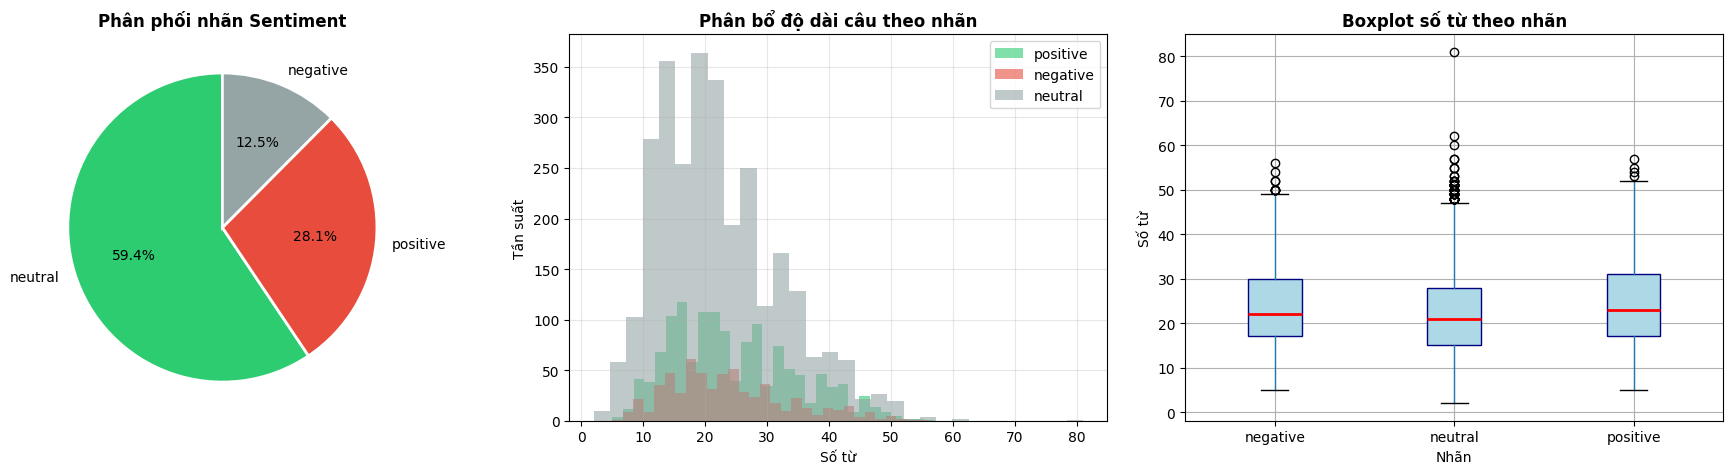

✅ Biểu đồ phân phối đã lưu.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('📊 Phân tích Dữ liệu FinancialPhraseBank', fontsize=15, fontweight='bold')

label_counts = df_en['label'].value_counts()
colors = ['#2ecc71', '#e74c3c', '#95a5a6']
axes[0].pie(label_counts.values, labels=label_counts.index,
            autopct='%1.1f%%', colors=colors, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Phân phối nhãn Sentiment', fontsize=12, fontweight='bold')

for lbl, color in zip(['positive', 'negative', 'neutral'], colors):
    subset = df_en[df_en['label'] == lbl]['word_count']
    axes[1].hist(subset, bins=30, alpha=0.6, label=lbl, color=color)
axes[1].set_xlabel('Số từ'); axes[1].set_ylabel('Tần suất')
axes[1].set_title('Phân bổ độ dài câu theo nhãn', fontsize=12, fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.3)

df_en.boxplot(column='word_count', by='label', ax=axes[2], patch_artist=True,
              boxprops=dict(facecolor='lightblue', color='navy'),
              medianprops=dict(color='red', linewidth=2))
axes[2].set_title('Boxplot số từ theo nhãn', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Nhãn'); axes[2].set_ylabel('Số từ')
plt.suptitle('')
plt.tight_layout()
plt.savefig('eda_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Biểu đồ phân phối đã lưu.')


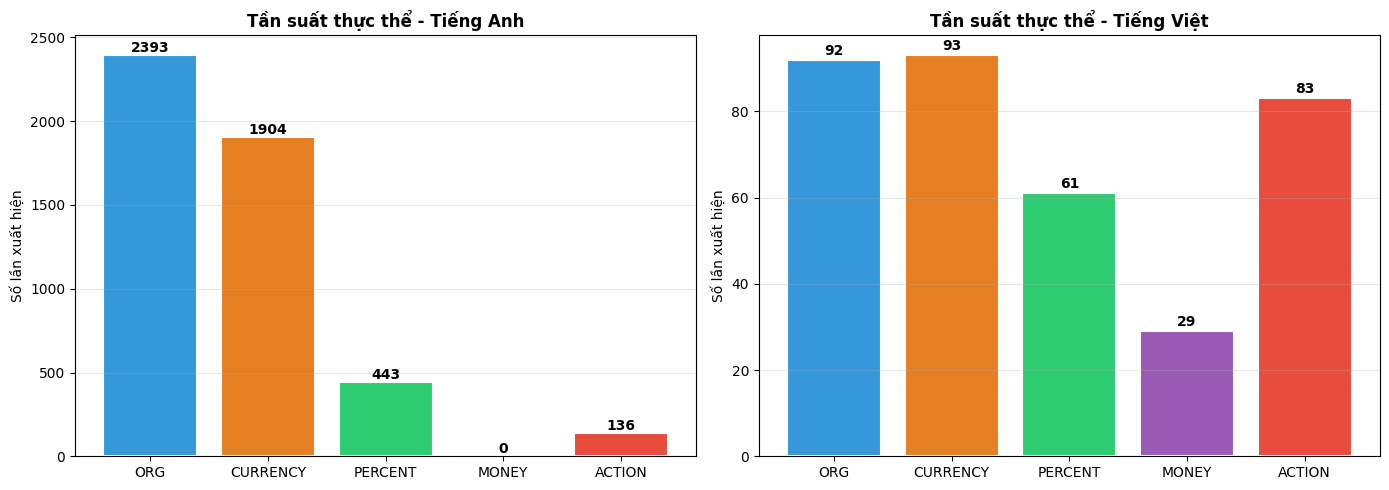

✅ Biểu đồ thực thể đã lưu.


In [ ]:
import re

FINANCIAL_ENTITIES = {
    'ORG':      ['company', 'bank', 'fund', 'corp', 'inc', 'ltd', 'group', 'exchange',
                 'ngân hàng', 'công ty', 'tập đoàn', 'quỹ', 'sàn'],
    'CURRENCY': ['EUR', 'USD', 'GBP', 'BTC', 'ETH', 'XRP', 'BNB', 'USDT',
                 'đồng', 'tỷ đồng', 'triệu đồng'],
    'PERCENT':  [r'\d+\.?\d*\s*%'],
    'MONEY':    [r'EUR\s*\d+', r'USD\s*\d+', r'\$\d+', r'\d+\s*tỷ', r'\d+\s*triệu'],
    'ACTION':   ['acquired', 'merged', 'launched', 'raised', 'fell', 'surged',
                 'niêm yết', 'sáp nhập', 'phát hành', 'tăng', 'giảm', 'bị hack'],
}

def count_entities(texts, entities_dict):
    counts = {k: 0 for k in entities_dict}
    for text in texts:
        text_lower = text.lower()
        for etype, patterns in entities_dict.items():
            for pat in patterns:
                # FIX 4: dùng pat[0] == '\\' thay vì startswith(r'\\')
                if pat and pat[0] == '\\':
                    counts[etype] += len(re.findall(pat, text, re.IGNORECASE))
                else:
                    counts[etype] += text_lower.count(pat.lower())
    return counts

en_entity_counts = count_entities(df_en['text'].tolist(), FINANCIAL_ENTITIES)
vi_entity_counts = count_entities(df_vi['text'].tolist(), FINANCIAL_ENTITIES)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bar_colors = ['#3498db','#e67e22','#2ecc71','#9b59b6','#e74c3c']
for ax, (counts, title) in zip(axes, [
    (en_entity_counts, 'Tần suất thực thể - Tiếng Anh'),
    (vi_entity_counts, 'Tần suất thực thể - Tiếng Việt')
]):
    bars = ax.bar(counts.keys(), counts.values(),
                  color=bar_colors[:len(counts)], edgecolor='white', linewidth=1.5)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Số lần xuất hiện')
    ax.grid(axis='y', alpha=0.3)
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                str(int(bar.get_height())), ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig('eda_entities.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Biểu đồ thực thể đã lưu.')


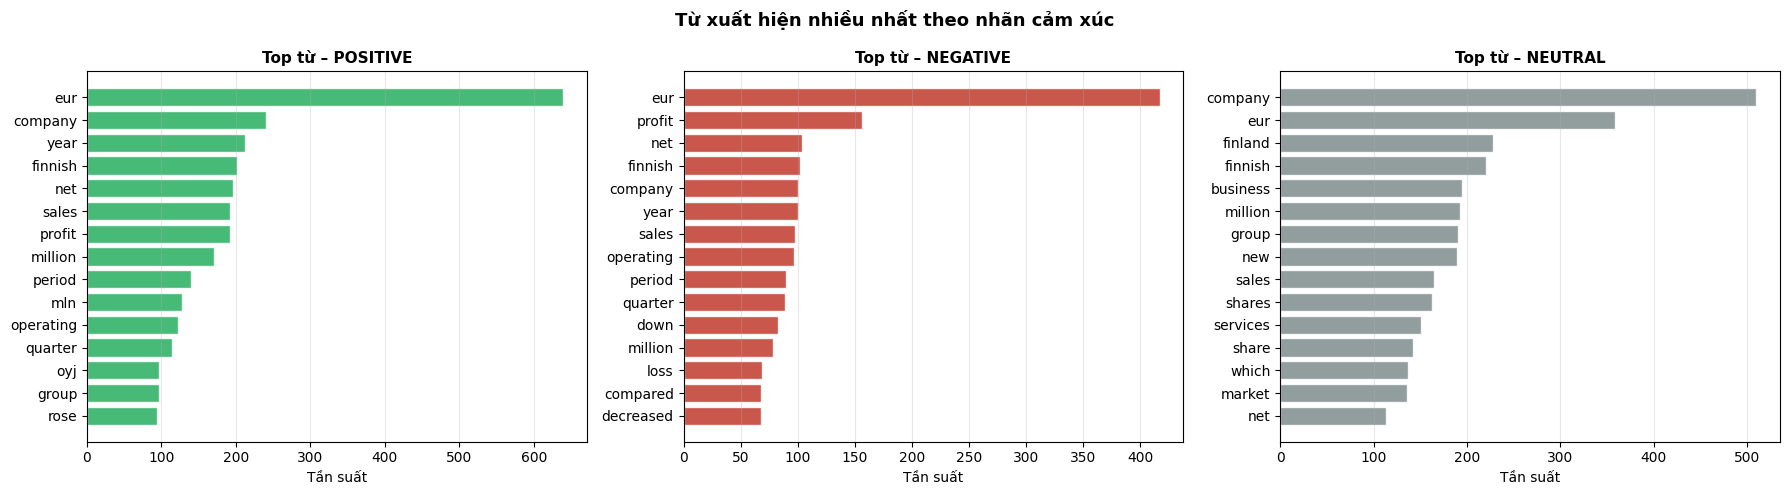

In [ ]:
from collections import Counter

STOPWORDS = {'the','a','an','is','are','was','were','in','of','to','and','for',
             'its','at','by','with','on','from','that','this','it','as','be',
             'has','had','have','will','said','also','more','than','per','cent'}

def get_top_words(texts, n=15):
    words = []
    for t in texts:
        words.extend([w.lower() for w in re.findall(r'[A-Za-z]{3,}', t)
                      if w.lower() not in STOPWORDS])
    return Counter(words).most_common(n)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, lbl, color in zip(axes,
                           ['positive', 'negative', 'neutral'],
                           ['#27ae60', '#c0392b', '#7f8c8d']):
    subset = df_en[df_en['label'] == lbl]['text']
    top = get_top_words(subset)
    if not top:
        continue
    words, freqs = zip(*top)
    ax.barh(words[::-1], freqs[::-1], color=color, alpha=0.85, edgecolor='white')
    ax.set_title(f'Top từ – {lbl.upper()}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Tần suất'); ax.grid(axis='x', alpha=0.3)
plt.suptitle('Từ xuất hiện nhiều nhất theo nhãn cảm xúc', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_topwords.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 🛠️ BƯỚC 3: TIỀN XỬ LÝ & BIO TAGGING

In [ ]:
def clean_text(text):
    """Làm sạch văn bản tài chính."""
    text = re.sub(r'<[^>]+>', ' ', text)            # xóa HTML
    text = re.sub(r'\s+', ' ', text).strip()        # chuẩn hóa khoảng trắng
    text = re.sub(r'[^\w\s\.,;:\-\(\)%$€£¥@/]', '', text)  # giữ ký tự hữu ích
    return text

df_en['text_clean'] = df_en['text'].apply(clean_text)
df_vi['text_clean'] = df_vi['text'].apply(clean_text)

print('Trước khi làm sạch:')
print(df_en['text'].iloc[5])
print('\nSau khi làm sạch:')
print(df_en['text_clean'].iloc[5])


Trước khi làm sạch:
FINANCING OF ASPOCOMP 'S GROWTH Aspocomp is aggressively pursuing its growth strategy by increasingly focusing on technologically more demanding HDI printed circuit boards PCBs .

Sau khi làm sạch:
FINANCING OF ASPOCOMP S GROWTH Aspocomp is aggressively pursuing its growth strategy by increasingly focusing on technologically more demanding HDI printed circuit boards PCBs .


In [ ]:
"""
BIO Schema:
  B-ORG  : Bắt đầu tổ chức  |  I-ORG  : Tiếp nối tổ chức
  B-MONEY: Bắt đầu số tiền  |  I-MONEY: Tiếp nối số tiền
  B-ACT  : Bắt đầu hành động|  I-ACT  : Tiếp nối hành động
  B-PERC : Phần trăm        |  I-PERC : Tiếp nối phần trăm
  O      : Không phải thực thể
"""

ORG_PATTERNS = [
    r'\b([A-Z][a-z]+(?:\s+[A-Z][a-z]+)*\s+(?:Corp|Inc|Ltd|Bank|Group|Exchange|Fund|Capital))\b',
    r'\b(Binance|Coinbase|Kraken|FTX|BlackRock|JPMorgan|Goldman|VPBank|Techcombank|BIDV|VCB|Vietcombank|HOSE|HNX|SSI|MBBank|Vingroup|FPT|Masan|Ripple|Dragon\s+Capital)\b',
    r'\b(Bitcoin|Ethereum|Cardano|Solana|XRP|BNB|USDT|Poly\s+Network)\b',
]
MONEY_PATTERN  = r'(?:EUR|USD|GBP|VND)?\\s*\\d+(?:[,.]\\d+)*\\s*(?:million|billion|tỷ|triệu|nghìn)?\\s*(?:EUR|USD|GBP|VND|đồng)?'
PERCENT_PATTERN = r'\\d+(?:\\.\\d+)?\\s*%'
ACTION_KEYWORDS = [
    'acquired','merged','launched','raised','surged','fell','plunged',
    'hacked','stolen','breached','listed','IPO','bankrupt','resigned',
    'niêm yết','sáp nhập','phát hành','bị hack','từ chức','tăng','giảm'
]

def find_token_span(tokens, start_char):
    """Trả về index token tại vị trí char start_char."""
    char_count = 0
    for i, tok in enumerate(tokens):
        if char_count >= start_char:
            return i
        char_count += len(tok) + 1
    return len(tokens) - 1

def tokenize_and_bio_tag(text):
    """Tạo BIO tags cho một câu."""
    tokens = text.split()
    tags   = ['O'] * len(tokens)

    def tag_span(start_char, span_text, b_tag, i_tag):
        span_toks = span_text.split()
        idx = find_token_span(tokens, start_char)
        for j in range(len(span_toks)):
            if idx + j < len(tags):
                tags[idx + j] = b_tag if j == 0 else i_tag

    for m in re.finditer(MONEY_PATTERN, text, re.IGNORECASE):
        tag_span(m.start(), m.group(), 'B-MONEY', 'I-MONEY')
    for m in re.finditer(PERCENT_PATTERN, text):
        idx = find_token_span(tokens, m.start())
        if tags[idx] == 'O':
            tags[idx] = 'B-PERC'
    for pat in ORG_PATTERNS:
        for m in re.finditer(pat, text):
            idx = find_token_span(tokens, m.start())
            if tags[idx] == 'O':
                tag_span(m.start(), m.group(), 'B-ORG', 'I-ORG')
    for i, tok in enumerate(tokens):
        for act in ACTION_KEYWORDS:
            if act.lower() in tok.lower() and tags[i] == 'O':
                tags[i] = 'B-ACT'
                break
    return tokens, tags

print('📝 Đang tạo BIO tags...')
ner_data = []
for text in df_en['text_clean'].tolist() + df_vi['text_clean'].tolist():
    if len(text.strip()) > 10:
        toks, tags = tokenize_and_bio_tag(text)
        ner_data.append({'tokens': toks, 'ner_tags': tags})
print(f'✅ Đã tạo {len(ner_data)} mẫu NER')

print('\n📋 Ví dụ BIO tagging:')
ex = ner_data[5]
for tok, tag in zip(ex['tokens'][:15], ex['ner_tags'][:15]):
    print(f'  {tok:<20} {tag}')


📝 Đang tạo BIO tags...
✅ Đã tạo 4871 mẫu NER

📋 Ví dụ BIO tagging:
  FINANCING            O
  OF                   O
  ASPOCOMP             O
  S                    O
  GROWTH               O
  Aspocomp             O
  is                   O
  aggressively         O
  pursuing             O
  its                  O
  growth               O
  strategy             O
  by                   O
  increasingly         O
  focusing             O


Phân phối BIO tags:
  B-ACT       :     247 (0.21%)
  B-ORG       :     364 (0.31%)
  I-ORG       :     498 (0.42%)
  O           :  116887 (99.06%)


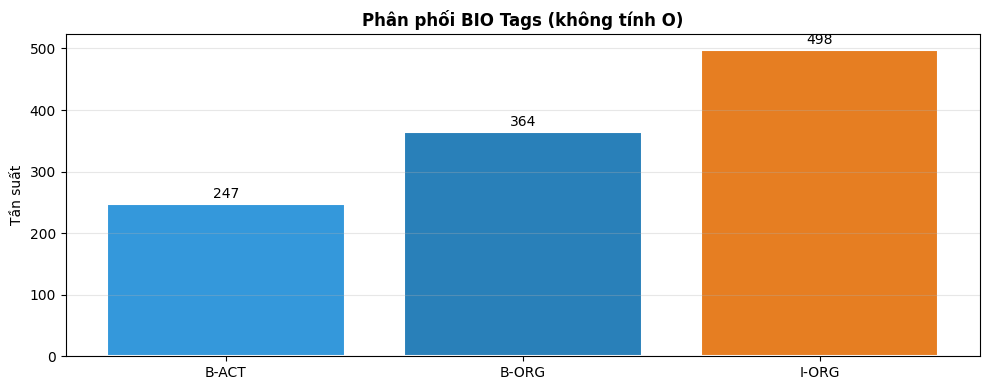

In [ ]:
all_tags  = [tag for s in ner_data for tag in s['ner_tags']]
tag_counts = Counter(all_tags)
print('Phân phối BIO tags:')
for tag, count in sorted(tag_counts.items()):
    print(f'  {tag:<12}: {count:>7} ({100*count/len(all_tags):.2f}%)')

non_o = {k: v for k, v in tag_counts.items() if k != 'O'}
all_colors = ['#3498db','#2980b9','#e67e22','#d35400','#27ae60','#1e8449','#8e44ad','#6c3483']
# FIX 5: slice colors to match number of bars
plot_colors = all_colors[:len(non_o)]
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(non_o.keys(), non_o.values(), color=plot_colors, edgecolor='white', linewidth=1.5)
ax.set_title('Phân phối BIO Tags (không tính O)', fontsize=12, fontweight='bold')
ax.set_ylabel('Tần suất'); ax.grid(axis='y', alpha=0.3)
for bar in ax.patches:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
            str(int(bar.get_height())), ha='center', va='bottom')
plt.tight_layout()
plt.savefig('bio_distribution.png', dpi=150)
plt.show()


---
## 🤖 BƯỚC 4: XÂY DỰNG MÔ HÌNH

In [ ]:
MODEL_NAME = 'xlm-roberta-base'
print(f'📦 Tải tokenizer: {MODEL_NAME}')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

LABEL2ID = {'negative': 0, 'neutral': 1, 'positive': 2}
ID2LABEL  = {v: k for k, v in LABEL2ID.items()}

# FIX 6: strip label whitespace trước khi map, astype(int) sau dropna
df_sent = df_en[df_en['label'].isin(LABEL2ID.keys())].copy()
df_sent['label'] = df_sent['label'].str.strip()
df_sent['label_id'] = df_sent['label'].map(LABEL2ID)
df_sent = df_sent.dropna(subset=['label_id'])
df_sent['label_id'] = df_sent['label_id'].astype(int)

X_train, X_val, y_train, y_val = train_test_split(
    df_sent['text_clean'].tolist(),
    df_sent['label_id'].tolist(),
    test_size=0.2, random_state=42, stratify=df_sent['label_id']
)
print(f'✅ Train: {len(X_train)}, Val: {len(X_val)}')


📦 Tải tokenizer: xlm-roberta-base


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ Train: 3876, Val: 970


In [ ]:
MAX_LEN = 128

class FinancialSentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=MAX_LEN):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_dataset = FinancialSentimentDataset(X_train, y_train, tokenizer)
val_dataset   = FinancialSentimentDataset(X_val,   y_val,   tokenizer)
print('✅ Dataset tạo xong.')
print(f'  Sample keys: {list(train_dataset[0].keys())}')


✅ Dataset tạo xong.
  Sample keys: ['input_ids', 'attention_mask', 'labels']


In [ ]:
print(f'📦 Tải mô hình: {MODEL_NAME} cho Sequence Classification')
sent_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=3, id2label=ID2LABEL, label2id=LABEL2ID
).to(DEVICE)

def compute_metrics(eval_pred):
    from sklearn.metrics import f1_score, precision_score, recall_score
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'f1':        f1_score(labels, preds, average='macro', zero_division=0),
        'precision': precision_score(labels, preds, average='macro', zero_division=0),
        'recall':    recall_score(labels, preds, average='macro', zero_division=0),
    }

# FIX 7: `import evaluate` đã xóa (không dùng)
training_args = TrainingArguments(
    output_dir='./sentiment_model',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    warmup_steps=200,
    weight_decay=0.01,
    learning_rate=2e-5,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    logging_steps=50,
    fp16=torch.cuda.is_available(),
    report_to='none',
)

trainer = Trainer(
    model=sent_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

print('🚀 Bắt đầu huấn luyện Sentiment model...')
trainer.train()
trainer.save_model('./sentiment_model_final')
print('✅ Huấn luyện & lưu Sentiment model hoàn tất!')


📦 Tải mô hình: xlm-roberta-base cho Sequence Classification


model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


🚀 Bắt đầu huấn luyện Sentiment model...


Epoch,Training Loss,Validation Loss,F1,Precision,Recall
1,0.808300,0.600719,0.567593,0.702251,0.577010
2,0.432900,0.378452,0.828813,0.815202,0.845057
3,0.218200,0.451771,0.822675,0.802328,0.850810


✅ Huấn luyện & lưu Sentiment model hoàn tất!


In [ ]:
NER_LABELS   = ['O','B-ORG','I-ORG','B-MONEY','I-MONEY','B-ACT','I-ACT','B-PERC','I-PERC']
NER_LABEL2ID = {l: i for i, l in enumerate(NER_LABELS)}
NER_ID2LABEL = {i: l for i, l in enumerate(NER_LABELS)}

class NERDataset(Dataset):
    def __init__(self, samples, tokenizer, label2id, max_len=128):
        self.samples   = samples
        self.tokenizer = tokenizer
        self.label2id  = label2id
        self.max_len   = max_len

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample  = self.samples[idx]
        tokens  = sample['tokens']
        tag_ids = [self.label2id.get(t, 0) for t in sample['ner_tags']]
        enc = self.tokenizer(
            tokens, is_split_into_words=True,
            max_length=self.max_len, padding='max_length',
            truncation=True, return_tensors='pt'
        )
        word_ids = enc.word_ids()
        aligned  = []
        prev_wid = None
        for wid in word_ids:
            if wid is None:
                aligned.append(-100)
            elif wid != prev_wid:
                aligned.append(tag_ids[wid] if wid < len(tag_ids) else 0)
            else:
                aligned.append(-100)
            prev_wid = wid
        return {
            'input_ids':      enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'labels':         torch.tensor(aligned, dtype=torch.long)
        }

ner_train_raw, ner_val_raw = train_test_split(ner_data, test_size=0.2, random_state=42)
ner_train_ds = NERDataset(ner_train_raw, tokenizer, NER_LABEL2ID)
ner_val_ds   = NERDataset(ner_val_raw,   tokenizer, NER_LABEL2ID)
print(f'✅ NER datasets: Train={len(ner_train_ds)}, Val={len(ner_val_ds)}')


✅ NER datasets: Train=3896, Val=975


In [ ]:
print(f'📦 Tải NER model: {MODEL_NAME}')
ner_model = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME, num_labels=len(NER_LABELS),
    id2label=NER_ID2LABEL, label2id=NER_LABEL2ID,
    ignore_mismatched_sizes=True
).to(DEVICE)

def compute_ner_metrics(eval_pred):
    from seqeval.metrics import f1_score, precision_score, recall_score
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    true_preds, true_labels = [], []
    for pred_row, label_row in zip(preds, labels):
        tp, tl = [], []
        for p, l in zip(pred_row, label_row):
            if l != -100:
                tp.append(NER_ID2LABEL[p])
                tl.append(NER_ID2LABEL[l])
        true_preds.append(tp); true_labels.append(tl)
    return {
        'ner_f1':        f1_score(true_labels, true_preds),
        'ner_precision': precision_score(true_labels, true_preds),
        'ner_recall':    recall_score(true_labels, true_preds),
    }

ner_training_args = TrainingArguments(
    output_dir='./ner_model',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    warmup_steps=100,
    weight_decay=0.01,
    learning_rate=3e-5,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='ner_f1',
    logging_steps=50,
    fp16=torch.cuda.is_available(),
    report_to='none',
)

ner_trainer = Trainer(
    model=ner_model, args=ner_training_args,
    train_dataset=ner_train_ds, eval_dataset=ner_val_ds,
    compute_metrics=compute_ner_metrics,
)
print('🚀 Huấn luyện NER model...')
ner_trainer.train()
ner_trainer.save_model('./ner_model_final')
print('✅ NER model hoàn tất!')


📦 Tải NER model: xlm-roberta-base


Some weights of XLMRobertaForTokenClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


🚀 Huấn luyện NER model...


Epoch,Training Loss,Validation Loss,Ner F1,Ner Precision,Ner Recall
1,0.045100,0.020921,0.237624,0.279070,0.206897
2,0.012200,0.007732,0.731518,0.666667,0.810345
3,0.008600,0.005762,0.873950,0.852459,0.896552


✅ NER model hoàn tất!


In [ ]:
"""
Event Types: 0-Niêm yết/IPO, 1-Bị hack, 2-Thay đổi nhân sự,
             3-Sáp nhập/Mua lại, 4-Kết quả tài chính, 5-Biến động giá
"""

ID2EVENT = {
    0: 'niêm yết / IPO',
    1: 'bị hack / tấn công',
    2: 'thay đổi nhân sự',
    3: 'sáp nhập / mua lại',
    4: 'kết quả tài chính',
    5: 'biến động giá',
}

EVENT_RULES = [
    (0, ['niêm yết','IPO','listed','listing','goes public','phát hành cổ phiếu']),
    (1, ['hack','hacked','stolen','breach','cyber attack','tấn công','bị đánh cắp']),
    (2, ['CEO','resign','appointed','từ chức','bổ nhiệm','thay thế','nhân sự','lãnh đạo']),
    (3, ['acquired','merged','merger','acquisition','sáp nhập','mua lại','thâu tóm']),
    (4, ['profit','revenue','earnings','loss','quarterly','lợi nhuận','doanh thu','quý']),
    (5, ['surged','plunged','rose','fell','tăng','giảm','lập đỉnh','biến động','%']),
]

def classify_event(text):
    """Rule-based event classification (returns 0-5, or -1 nếu không rõ)."""
    text_lower = text.lower()
    scores = [0] * 6
    for event_id, keywords in EVENT_RULES:
        for kw in keywords:
            if kw.lower() in text_lower:
                scores[event_id] += 1
    best = max(range(6), key=lambda i: scores[i])
    return best if scores[best] > 0 else -1

all_texts   = df_en['text_clean'].tolist() + df_vi['text_clean'].tolist()
raw_ev_ids  = [classify_event(t) for t in all_texts]

# FIX 9: bỏ samples không xác định (-1) → labels 0-5 liên tục
df_event = pd.DataFrame({'text': all_texts, 'event_type': raw_ev_ids})
df_event = df_event[df_event['event_type'] >= 0].copy()

print('Phân phối loại sự kiện:')
for eid, ename in ID2EVENT.items():
    count = (df_event['event_type'] == eid).sum()
    print(f'  [{eid}] {ename:<25}: {count}')

X_ev_train, X_ev_val, y_ev_train, y_ev_val = train_test_split(
    df_event['text'].tolist(),
    df_event['event_type'].tolist(),
    test_size=0.2, random_state=42
)
print(f'\nEvent classifier: Train={len(X_ev_train)}, Val={len(X_ev_val)}')


Phân phối loại sự kiện:
  [0] niêm yết / IPO           : 30
  [1] bị hack / tấn công       : 3
  [2] thay đổi nhân sự         : 85
  [3] sáp nhập / mua lại       : 123
  [4] kết quả tài chính        : 595
  [5] biến động giá            : 329

Event classifier: Train=932, Val=233


In [ ]:
# FIX 8: HuggingFace yêu cầu label2id keys là str, id2label keys là int
EV_NUM_LABELS = 6  # 0-5 sau khi loại bỏ 'Khác'
EVENT_LABEL2ID = {str(i): i for i in range(EV_NUM_LABELS)}  # {'0':0, '1':1, ...}
EVENT_ID2LABEL = {i: ID2EVENT[i] for i in range(EV_NUM_LABELS)}

event_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=EV_NUM_LABELS,
    id2label=EVENT_ID2LABEL,
    label2id=EVENT_LABEL2ID,
    ignore_mismatched_sizes=True
).to(DEVICE)

ev_train_ds = FinancialSentimentDataset(X_ev_train, y_ev_train, tokenizer)
ev_val_ds   = FinancialSentimentDataset(X_ev_val,   y_ev_val,   tokenizer)

ev_training_args = TrainingArguments(
    output_dir='./event_model',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    logging_steps=50,
    fp16=torch.cuda.is_available(),
    report_to='none',
)

ev_trainer = Trainer(
    model=event_model, args=ev_training_args,
    train_dataset=ev_train_ds, eval_dataset=ev_val_ds,
    compute_metrics=compute_metrics,
)
print('🚀 Huấn luyện Event Classifier...')
ev_trainer.train()
ev_trainer.save_model('./event_model_final')
print('✅ Event Classifier hoàn tất!')


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


🚀 Huấn luyện Event Classifier...


Epoch,Training Loss,Validation Loss,F1,Precision,Recall
1,1.196300,0.724254,0.294404,0.407699,0.322495
2,0.710800,0.452508,0.545215,0.576885,0.555768
3,0.427900,0.391325,0.607889,0.600815,0.615695


✅ Event Classifier hoàn tất!


---
## 📈 BƯỚC 5: ĐÁNH GIÁ MÔ HÌNH

In [ ]:
def evaluate_model(trainer_obj, dataset):
    predictions = trainer_obj.predict(dataset)
    preds  = np.argmax(predictions.predictions, axis=-1)
    labels = predictions.label_ids
    return preds, labels

print('📊 Đánh giá Sentiment Model...')
sent_preds, sent_labels = evaluate_model(trainer, val_dataset)
print('\n=== Báo cáo phân loại Sentiment ===')
print(classification_report(
    sent_labels, sent_preds,
    target_names=[ID2LABEL[i] for i in range(3)],
    digits=4
))


📊 Đánh giá Sentiment Model...



=== Báo cáo phân loại Sentiment ===
              precision    recall  f1-score   support

    negative     0.7630    0.8512    0.8047       121
     neutral     0.9026    0.8524    0.8768       576
    positive     0.7801    0.8315    0.8050       273

    accuracy                         0.8464       970
   macro avg     0.8152    0.8451    0.8288       970
weighted avg     0.8507    0.8464    0.8476       970



📊 Đánh giá Event Classifier...


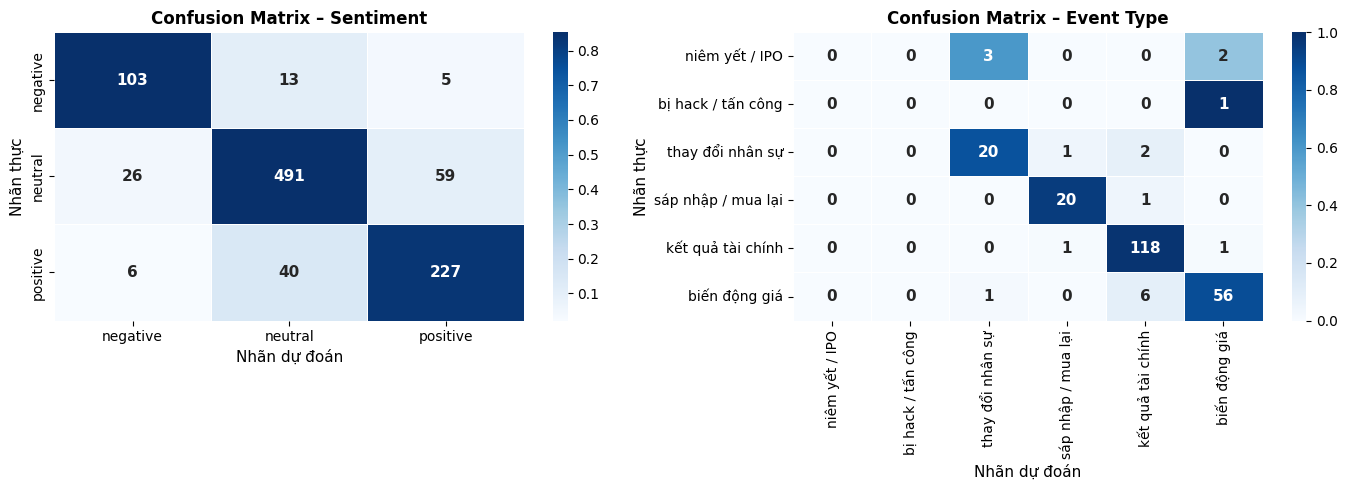

✅ Confusion Matrix đã lưu.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

def plot_confusion_matrix(ax, labels, preds, class_names, title):
    cm      = confusion_matrix(labels, preds)
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=cm, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                ax=ax, linewidths=0.5, annot_kws={'size':11,'weight':'bold'})
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Nhãn thực', fontsize=11)
    ax.set_xlabel('Nhãn dự đoán', fontsize=11)

plot_confusion_matrix(axes[0], sent_labels, sent_preds,
                      ['negative','neutral','positive'],
                      'Confusion Matrix – Sentiment')

print('📊 Đánh giá Event Classifier...')
ev_preds, ev_labels = evaluate_model(ev_trainer, ev_val_ds)
unique_evs = sorted(set(ev_labels.tolist()))
ev_names   = [EVENT_ID2LABEL.get(i, f'Event {i}') for i in unique_evs]
plot_confusion_matrix(axes[1], ev_labels, ev_preds,
                      ev_names, 'Confusion Matrix – Event Type')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Confusion Matrix đã lưu.')


In [ ]:
print('📊 Đánh giá NER Model...')
from seqeval.metrics import classification_report as ner_report
ner_out      = ner_trainer.predict(ner_val_ds)
ner_pred_ids = np.argmax(ner_out.predictions, axis=-1)
ner_true_ids = ner_out.label_ids
true_seqs, pred_seqs = [], []
for pred_row, label_row in zip(ner_pred_ids, ner_true_ids):
    tp, tl = [], []
    for p, l in zip(pred_row, label_row):
        if l != -100:
            tp.append(NER_ID2LABEL[p]); tl.append(NER_ID2LABEL[l])
    pred_seqs.append(tp); true_seqs.append(tl)
print('\n=== Báo cáo NER (seqeval) ===')
print(ner_report(true_seqs, pred_seqs, digits=4))


📊 Đánh giá NER Model...



=== Báo cáo NER (seqeval) ===
              precision    recall  f1-score   support

         ACT     0.8788    0.9062    0.8923        32
         ORG     0.8427    0.8929    0.8671        84

   micro avg     0.8525    0.8966    0.8739       116
   macro avg     0.8607    0.8996    0.8797       116
weighted avg     0.8527    0.8966    0.8740       116



📊 TÓM TẮT KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH
  Sentiment  (XLM-RoBERTa):
    Precision : 0.8152 | Recall : 0.8451 | F1 : 0.8288
  Event Type (XLM-RoBERTa):
    Precision : 0.6008 | Recall : 0.6157 | F1 : 0.6079


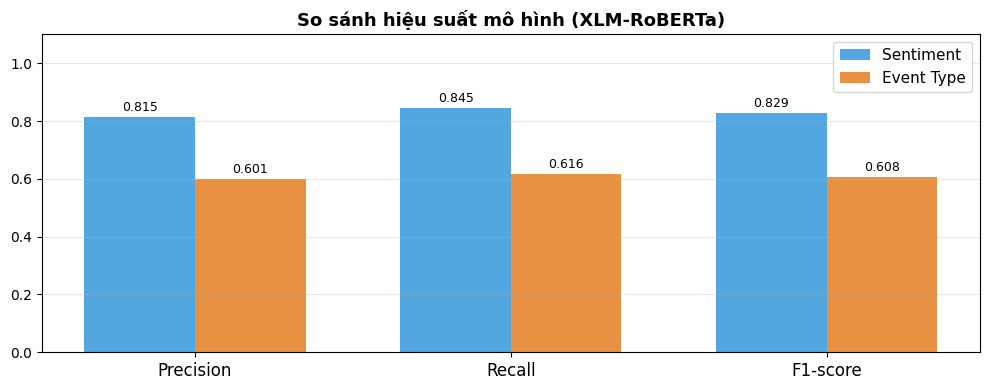

In [ ]:
from sklearn.metrics import f1_score, precision_score, recall_score

sent_f1   = f1_score(sent_labels, sent_preds, average='macro', zero_division=0)
sent_prec = precision_score(sent_labels, sent_preds, average='macro', zero_division=0)
sent_rec  = recall_score(sent_labels, sent_preds, average='macro', zero_division=0)
ev_f1     = f1_score(ev_labels, ev_preds, average='macro', zero_division=0)
ev_prec   = precision_score(ev_labels, ev_preds, average='macro', zero_division=0)
ev_rec    = recall_score(ev_labels, ev_preds, average='macro', zero_division=0)

print('=' * 55)
print('📊 TÓM TẮT KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH')
print('=' * 55)
for name, (p, r, f) in [
    ('Sentiment  (XLM-RoBERTa)', (sent_prec, sent_rec, sent_f1)),
    ('Event Type (XLM-RoBERTa)', (ev_prec,   ev_rec,   ev_f1)),
]:
    print(f'  {name}:')
    print(f'    Precision : {p:.4f} | Recall : {r:.4f} | F1 : {f:.4f}')
print('=' * 55)

fig, ax = plt.subplots(figsize=(10, 4))
metrics   = ['Precision', 'Recall', 'F1-score']
x = np.arange(len(metrics)); w = 0.35
ax.bar(x - w/2, [sent_prec, sent_rec, sent_f1], w, label='Sentiment',   color='#3498db', alpha=0.85)
ax.bar(x + w/2, [ev_prec,   ev_rec,   ev_f1],   w, label='Event Type',  color='#e67e22', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0, 1.1)
ax.set_title('So sánh hiệu suất mô hình (XLM-RoBERTa)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11); ax.grid(axis='y', alpha=0.3)
for bar in ax.patches:
    h = bar.get_height()
    if h > 0.01:
        ax.text(bar.get_x()+bar.get_width()/2, h+0.01, f'{h:.3f}',
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()


---
## 🌐 BƯỚC 6: ỨNG DỤNG DEMO – FLASK + NGROK TRÊN COLAB

In [4]:
%%capture
!pip install flask flask-cors pyngrok


In [5]:
from pyngrok import ngrok, conf

# Lấy token tại: https://dashboard.ngrok.com/get-started/your-authtoken
NGROK_TOKEN = '3CcX7RumkIY0ejlZHBiBXLbbu1U_68GaTk6AURtJ6SBEKiace'
if NGROK_TOKEN != 'YOUR_NGROK_AUTHTOKEN':
    conf.get_default().auth_token = NGROK_TOKEN
    print('✅ Ngrok đã xác thực.')
else:
    print('⚠️  Vui lòng thay NGROK_TOKEN bằng token thực của bạn.')
    print('   Đăng ký miễn phí tại: https://dashboard.ngrok.com')


✅ Ngrok đã xác thực.


In [6]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AutoModelForTokenClassification
import re # Added
import requests # Added
from bs4 import BeautifulSoup # Added

# --- Utility functions and global variables for inference ---
ORG_PATTERNS = [
    r'\b([A-Z][a-z]+(?:\s+[A-Z][a-z]+)*\s+(?:Corp|Inc|Ltd|Bank|Group|Exchange|Fund|Capital))\b',
    r'\b(Binance|Coinbase|Kraken|FTX|BlackRock|JPMorgan|Goldman|VPBank|Techcombank|BIDV|VCB|Vietcombank|HOSE|HNX|SSI|MBBank|Vingroup|FPT|Masan|Ripple|Dragon\s+Capital)\b',
    r'\b(Bitcoin|Ethereum|Cardano|Solana|XRP|BNB|USDT|Poly\s+Network)\b',
]
MONEY_PATTERN  = r'(?:EUR|USD|GBP|VND)?\\s*\\d+(?:[,.]\\d+)*\\s*(?:million|billion|tỷ|triệu|nghìn)?\\s*(?:EUR|USD|GBP|VND|đồng)?'
PERCENT_PATTERN = r'\\d+(?:\\.\\d+)?\\s*%' # Escaped backslashes
ACTION_KEYWORDS = [
    'acquired','merged','launched','raised','surged','fell','plunged',
    'hacked','stolen','breached','listed','IPO','bankrupt','resigned',
    'niêm yết','sáp nhập','phát hành','bị hack','từ chức','bổ nhiệm','tăng','giảm'
]

def clean_text(text):
    """Làm sạch văn bản tài chính."""
    text = re.sub(r'<[^>]+>', ' ', text)            # xóa HTML
    text = re.sub(r'\s+', ' ', text).strip()        # chuẩn hóa khoảng trắng
    text = re.sub(r'[^\w\s\.,;:\-\(%\)$€£¥@/]', '', text)  # giữ ký tự hữu ích
    return text

def find_token_span(tokens, start_char):
    """Trả về index token tại vị trí char start_char."""
    char_count = 0
    for i, tok in enumerate(tokens):
        if char_count >= start_char:
            return i
        char_count += len(tok) + 1 # +1 for space
    return len(tokens) - 1 if tokens else 0

def tokenize_and_bio_tag(text):
    """Tạo BIO tags cho một câu."""
    tokens = text.split()
    tags   = ['O'] * len(tokens)

    def tag_span(start_char, span_text, b_tag, i_tag):
        span_toks = span_text.split()
        idx = find_token_span(tokens, start_char)
        for j in range(len(span_toks)):
            if idx + j < len(tags):
                tags[idx + j] = b_tag if j == 0 else i_tag

    for m in re.finditer(MONEY_PATTERN, text, re.IGNORECASE):
        tag_span(m.start(), m.group(), 'B-MONEY', 'I-MONEY')
    for m in re.finditer(PERCENT_PATTERN, text):
        idx = find_token_span(tokens, m.start())
        if idx < len(tags) and tags[idx] == 'O':
            tags[idx] = 'B-PERC'
    for pat in ORG_PATTERNS:
        for m in re.finditer(pat, text):
            idx = find_token_span(tokens, m.start())
            if idx < len(tags) and tags[idx] == 'O':
                tag_span(m.start(), m.group(), 'B-ORG', 'I-ORG')
    for i, tok in enumerate(tokens):
        for act in ACTION_KEYWORDS:
            if act.lower() in tok.lower() and tags[i] == 'O':
                tags[i] = 'B-ACT'
                break
    return tokens, tags

ID2EVENT = {
    0: 'niêm yết / IPO',
    1: 'bị hack / tấn công',
    2: 'thay đổi nhân sự',
    3: 'sáp nhập / mua lại',
    4: 'kết quả tài chính',
    5: 'biến động giá',
}

EVENT_RULES = [
    (0, ['niêm yết','IPO','listed','listing','goes public','phát hành cổ phiếu']),
    (1, ['hack','hacked','stolen','breach','cyber attack','tấn công','bị đánh cắp']),
    (2, ['CEO','resign','appointed','từ chức','bổ nhiệm','thay thế','nhân sự','lãnh đạo']),
    (3, ['acquired','merged','merger','acquisition','sáp nhập','mua lại','thâu tóm']),
    (4, ['profit','revenue','earnings','loss','quarterly','lợi nhuận','doanh thu','quý']),
    (5, ['surged','plunged','rose','fell','tăng','giảm','lập đỉnh','biến động','%']),
]

def classify_event(text):
    """Rule-based event classification (returns 0-5, or -1 nếu không rõ)."""
    text_lower = text.lower()
    scores = [0] * 6
    for event_id, keywords in EVENT_RULES:
        for kw in keywords:
            if kw.lower() in text_lower:
                scores[event_id] += 1
    best = max(range(6), key=lambda i: scores[i])
    return best if scores[best] > 0 else -1

# --- Inference components loading ---
def load_inference_components():
    MODEL_NAME = 'xlm-roberta-base'
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Define label mappings (copied from previous cells for self-containment)
    # Sentiment labels
    LABEL2ID = {'negative': 0, 'neutral': 1, 'positive': 2}
    ID2LABEL = {v: k for k, v in LABEL2ID.items()}

    # NER labels
    NER_LABELS = ['O','B-ORG','I-ORG','B-MONEY','I-MONEY','B-ACT','I-ACT','B-PERC','I-PERC']
    NER_LABEL2ID = {l: i for i, l in enumerate(NER_LABELS)}
    NER_ID2LABEL = {i: l for i, l in enumerate(NER_LABELS)}

    # Event labels
    EV_NUM_LABELS = 6
    EVENT_LABEL2ID = {str(i): i for i in range(EV_NUM_LABELS)}
    EVENT_ID2LABEL = {i: ID2EVENT[i] for i in range(EV_NUM_LABELS)}

    print(f'📦 Đang tải tokenizer: {MODEL_NAME}')
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

    print('📦 Đang tải Sentiment Model...')
    sent_model = AutoModelForSequenceClassification.from_pretrained(
        './sentiment_model_final',
        num_labels=len(LABEL2ID),
        id2label=ID2LABEL,
        label2id=LABEL2ID
    ).to(DEVICE)

    print('📦 Đang tải NER Model...')
    ner_model = AutoModelForTokenClassification.from_pretrained(
        './ner_model_final',
        num_labels=len(NER_LABELS),
        id2label=NER_ID2LABEL,
        label2id=NER_LABEL2ID,
        ignore_mismatched_sizes=True
    ).to(DEVICE)

    print('📦 Đang tải Event Model...')
    event_model = AutoModelForSequenceClassification.from_pretrained(
        './event_model_final',
        num_labels=EV_NUM_LABELS,
        id2label=EVENT_ID2LABEL,
        label2id=EVENT_LABEL2ID,
        ignore_mismatched_sizes=True
    ).to(DEVICE)

    return tokenizer, sent_model, ner_model, event_model, DEVICE, LABEL2ID, ID2LABEL, NER_LABELS, NER_LABEL2ID, NER_ID2LABEL, ID2EVENT, EV_NUM_LABELS, EVENT_LABEL2ID, EVENT_ID2LABEL

# Call the function to load everything into global scope
tokenizer, sent_model, ner_model, event_model, DEVICE, LABEL2ID, ID2LABEL, NER_LABELS, NER_LABEL2ID, NER_ID2LABEL, ID2EVENT, EV_NUM_LABELS, EVENT_LABEL2ID, EVENT_ID2LABEL = load_inference_components()
print('✅ Đã tải tất cả tokenizer và mô hình để inference.')


📦 Đang tải tokenizer: xlm-roberta-base


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

...

📦 Đang tải NER Model...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

📦 Đang tải Event Model...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✅ Đã tải tất cả tokenizer và mô hình để inference.


In [7]:
import json # Import json module here
from transformers import pipeline as hf_pipeline

# Tải pipeline inference
try:
    # Use the globally loaded tokenizer and models
    sent_pipe  = hf_pipeline('text-classification', model=sent_model,
                              tokenizer=tokenizer, device=0 if torch.cuda.is_available() else -1)
    event_pipe = hf_pipeline('text-classification', model=event_model,
                              tokenizer=tokenizer, device=0 if torch.cuda.is_available() else -1)
    # FIX 10: aggregation_strategy='simple' trả về entity_group là tên thuần: 'ORG', 'MONEY'...
    ner_pipe   = hf_pipeline('token-classification', model=ner_model,
                              tokenizer=tokenizer, aggregation_strategy='simple',
                              device=0 if torch.cuda.is_available() else -1)
    print('✅ Đã tải tất cả pipeline.')
except Exception as e:
    print(f'⚠️  Dùng rule-based fallback: {e}')
    sent_pipe = event_pipe = ner_pipe = None

def scrape_article(url):
    headers = {'User-Agent': 'Mozilla/5.0', 'Accept-Language': 'vi-VN,vi;q=0.9'}
    try:
        resp  = requests.get(url, headers=headers, timeout=15)
        resp.raise_for_status()
        soup  = BeautifulSoup(resp.text, 'html.parser')
        title = soup.find('h1')
        title = title.get_text(strip=True) if title else 'Không có tiêu đề'
        paras = [p.get_text(strip=True) for p in soup.find_all('p')
                 if len(p.get_text(strip=True)) > 30]
        return {'title': title, 'text': ' '.join([title]+paras[:10])[:2000], 'success': True}
    except Exception as e:
        return {'title': '', 'text': '', 'success': False, 'error': str(e)}

SENT_VI = {'positive': '✅ Tích cực', 'negative': '❌ Tiêu cực', 'neutral': '➖ Trung lập'}

def extract_events(text):
    text_c = clean_text(text[:512])

    # --- Sentiment ---
    if sent_pipe:
        try:
            s = sent_pipe(text_c, truncation=True)[0]
            sent_label, sent_score = s['label'], round(s['score'], 4)
        except Exception:
            sent_label, sent_score = 'neutral', 0.5
    else:
        pos = sum(1 for w in ['tăng','lợi nhuận','đỉnh','surged','profit'] if w in text.lower())
        neg = sum(1 for w in ['giảm','lỗ','hack','phạt','fell','loss'] if w in text.lower())
        sc  = pos - neg
        sent_label = 'positive' if sc > 0 else ('negative' if sc < 0 else 'neutral')
        sent_score = min(abs(sc)/5 + 0.5, 0.99)

    # --- Event Type ---
    if event_pipe:
        try:
            ev = event_pipe(text_c, truncation=True)[0]
            raw = ev['label']  # e.g. 'LABEL_2' or '2'
            ev_id = int(raw.replace('LABEL_', ''))
            ev_label = EVENT_ID2LABEL.get(ev_id, 'khác')
            ev_score = round(ev['score'], 4)
        except Exception:
            ev_id    = classify_event(text)
            ev_label = ID2EVENT.get(ev_id, 'khác')
            ev_score = 0.75
    else:
        ev_id    = classify_event(text)
        ev_label = ID2EVENT.get(ev_id, 'khác') if ev_id >= 0 else 'khác'
        ev_score = 0.75

    # --- NER ---
    entities = {'ORG': [], 'MONEY': [], 'ACT': [], 'PERC': []}
    if ner_pipe:
        try:
            # FIX 10: aggregation_strategy='simple' → entity_group = 'ORG', 'MONEY', ...
            for ent in ner_pipe(text_c[:512]):
                etype = ent['entity_group']  # already clean, no replace needed
                if etype in entities:
                    entities[etype].append(ent['word'].strip())
        except Exception:
            pass
    else:
        toks, tags = tokenize_and_bio_tag(text_c)
        cur_ent, cur_type = [], None
        for tok, tag in zip(toks, tags):
            if tag.startswith('B-'):
                if cur_ent and cur_type and cur_type in entities:
                    entities[cur_type].append(' '.join(cur_ent))
                cur_ent, cur_type = [tok], tag[2:]
            elif tag.startswith('I-') and cur_type == tag[2:]:
                cur_ent.append(tok)
            else:
                if cur_ent and cur_type and cur_type in entities:
                    entities[cur_type].append(' '.join(cur_ent))
                cur_ent, cur_type = [], None
    for k in entities:
        entities[k] = list(dict.fromkeys(entities[k]))  # dedup preserve order

    return {
        'sentiment':       SENT_VI.get(sent_label, sent_label),
        'sentiment_score': sent_score,
        'event_type':      ev_label.title(),
        'event_score':     ev_score,
        'entities':        entities,
        'summary':         text_c[:300] + ('...' if len(text_c) > 300 else '')
    }

# Kiểm tra nhanh
test = "Bitcoin tăng 15% sau khi BlackRock được SEC chấp thuận ETF, kéo toàn thị trường tăng mạnh."
print('🧪 Test extract_events():')
print(json.dumps(extract_events(test), ensure_ascii=False, indent=2))

✅ Đã tải tất cả pipeline.
🧪 Test extract_events():
{
  "sentiment": "✅ Tích cực",
  "sentiment_score": 0.9205,
  "event_type": "Biến Động Giá",
  "event_score": 0.75,
  "entities": {
    "ORG": [],
    "MONEY": [],
    "ACT": [
      "tăng"
    ],
    "PERC": []
  },
  "summary": "Bitcoin tăng 15% sau khi BlackRock được SEC chấp thuận ETF, kéo toàn thị trường tăng mạnh."
}


In [8]:
import threading
from flask import Flask, request, jsonify, Response
from flask_cors import CORS

HTML_PAGE = '''
<!DOCTYPE html><html lang="vi"><head>
<meta charset="UTF-8"><meta name="viewport" content="width=device-width, initial-scale=1.0">
<title>Event Extraction – Tin Tuc Tai Chinh</title>
<style>
*{box-sizing:border-box;margin:0;padding:0}
body{font-family:'Segoe UI',sans-serif;background:linear-gradient(135deg,#0f2027,#203a43,#2c5364);min-height:100vh;color:#eee}
.container{max-width:900px;margin:0 auto;padding:30px 20px}
h1{text-align:center;font-size:2rem;margin-bottom:8px;color:#4dd9ff}
.subtitle{text-align:center;color:#aaa;margin-bottom:30px;font-size:.95rem}
.card{background:rgba(255,255,255,.05);border:1px solid rgba(255,255,255,.1);border-radius:12px;padding:24px;margin-bottom:20px}
label{font-weight:600;color:#4dd9ff;display:block;margin-bottom:8px}
input[type=text],textarea{width:100%;padding:12px 16px;border-radius:8px;border:1px solid rgba(255,255,255,.2);background:rgba(255,255,255,.08);color:#eee;font-size:1rem;outline:none}
textarea{height:120px;resize:vertical}
.btn{background:linear-gradient(90deg,#4dd9ff,#0099cc);border:none;color:#fff;font-size:1rem;font-weight:700;padding:14px 32px;border-radius:8px;cursor:pointer;width:100%;margin-top:12px;transition:opacity .3s}
.btn:hover{opacity:.85}.btn:disabled{opacity:.5;cursor:not-allowed}
.btn2{background:linear-gradient(90deg,#ff6b9d,#c44569)}
.result-grid{display:grid;grid-template-columns:1fr 1fr;gap:16px;margin-top:20px}
.result-item{background:rgba(255,255,255,.07);border-radius:10px;padding:16px}
.result-item h3{font-size:.85rem;color:#aaa;text-transform:uppercase;letter-spacing:1px;margin-bottom:8px}
.result-item .value{font-size:1.3rem;font-weight:700;color:#4dd9ff}
.result-item .score{font-size:.8rem;color:#888;margin-top:4px}
.entity-section{margin-top:16px}
.entity-section h3{font-size:.85rem;color:#aaa;text-transform:uppercase;letter-spacing:1px;margin-bottom:10px}
.entity-group{display:flex;flex-wrap:wrap;gap:8px;margin-bottom:10px}
.elabel{font-size:.75rem;font-weight:700;margin-bottom:4px;color:#aaa}
.tag{padding:4px 12px;border-radius:20px;font-size:.85rem;font-weight:600}
.tag-ORG{background:#1a3a5c;color:#4dd9ff;border:1px solid #4dd9ff44}
.tag-MONEY{background:#1a3d1a;color:#4dff88;border:1px solid #4dff8844}
.tag-ACT{background:#3d1a1a;color:#ff6b6b;border:1px solid #ff6b6b44}
.tag-PERC{background:#2d1a3d;color:#b44dff;border:1px solid #b44dff44}
.summary-box{background:rgba(255,255,255,.05);border-left:3px solid #4dd9ff;padding:12px 16px;border-radius:4px;margin-top:16px;font-size:.9rem;line-height:1.6;color:#ccc}
.loading{text-align:center;padding:20px;color:#4dd9ff;font-size:1.1rem;display:none}
.spinner{display:inline-block;width:24px;height:24px;border:3px solid rgba(77,217,255,.3);border-top-color:#4dd9ff;border-radius:50%;animation:spin .8s linear infinite;margin-right:10px;vertical-align:middle}
@keyframes spin{to{transform:rotate(360deg)}}
.error{background:rgba(255,0,0,.1);border:1px solid #f44;border-radius:8px;padding:12px;color:#f88;margin-top:12px;display:none}
.divider{text-align:center;margin:16px 0;color:#555;font-size:.9rem}
@media(max-width:600px){.result-grid{grid-template-columns:1fr}}
</style></head><body>
<div class="container">
  <h1>Trich Xuat Su Kien Tai Chinh</h1>
  <p class="subtitle">Event Extraction da ngon ngu (Anh - Viet) | XLM-RoBERTa</p>
  <div class="card">
    <label>URL bai bao (CafeF, Reuters, Bloomberg...)</label>
    <input type="text" id="urlIn" placeholder="https://cafef.vn/..." />
    <button class="btn" id="btnUrl" onclick="doUrl()">Phan tich tu URL</button>
    <div class="divider">-- hoac nhap van ban truc tiep --</div>
    <label>Van ban tin tuc</label>
    <textarea id="txtIn" placeholder="Bitcoin tang 15% sau khi BlackRock duoc SEC chap thuan ETF..."></textarea>
    <button class="btn btn2" id="btnTxt" onclick="doText()">Phan tich van ban</button>
  </div>
  <div class="loading" id="loading"><span class="spinner"></span> Dang phan tich...</div>
  <div class="error" id="err"></div>
  <div id="results" style="display:none">
    <div class="card">
      <h2 style="color:#4dd9ff;margin-bottom:16px;">Ket qua phan tich</h2>
      <div class="result-grid">
        <div class="result-item"><h3>Cam xuc</h3><div class="value" id="rSent">-</div><div class="score" id="rSentS"></div></div>
        <div class="result-item"><h3>Loai su kien</h3><div class="value" id="rEv">-</div><div class="score" id="rEvS"></div></div>
      </div>
      <div class="entity-section">
        <h3>Thuc the nhan dien (NER)</h3>
        <div class="elabel">To chuc / Cong ty</div><div class="entity-group" id="eOrg"></div>
        <div class="elabel">Tien te / So tien</div><div class="entity-group" id="eMoney"></div>
        <div class="elabel">Hanh dong su kien</div><div class="entity-group" id="eAct"></div>
        <div class="elabel">Ty le / Phan tram</div><div class="entity-group" id="ePerc"></div>
      </div>
      <div class="summary-box" id="rSum"></div>
    </div>
  </div>
</div>
<script>
function busy(b){
  document.getElementById('loading').style.display=b?'block':'none';
  document.getElementById('results').style.display=b?'none':'block';
  document.getElementById('err').style.display='none';
  ['btnUrl','btnTxt'].forEach(id=>{document.getElementById(id).disabled=b;});
}
function tags(id,items,cls){
  document.getElementById(id).innerHTML=items&&items.length
    ?items.map(t=>`<span class="tag tag-${cls}">${t}</span>`).join('')
    :'<span style="color:#555">Khong phat hien</span>';
}
function render(d){
  document.getElementById('rSent').textContent=d.sentiment||'-';
  document.getElementById('rSentS').textContent='Do tin cay: '+(d.sentiment_score*100).toFixed(1)+'%';
  document.getElementById('rEv').textContent=d.event_type||'-';
  document.getElementById('rEvS').textContent='Do tin cay: '+(d.event_score*100).toFixed(1)+'%';
  tags('eOrg',  d.entities.ORG,   'ORG');
  tags('eMoney',d.entities.MONEY, 'MONEY');
  tags('eAct',  d.entities.ACT,   'ACT');
  tags('ePerc', d.entities.PERC,  'PERC');
  document.getElementById('rSum').textContent='Van ban: '+(d.summary||'');
  document.getElementById('results').style.display='block';
  busy(false);
}
async function call(ep,body){
  busy(true);
  try{
    const r=await fetch(ep,{method:'POST',headers:{'Content-Type':'application/json'},body:JSON.stringify(body)});
    const d=await r.json();
    if(d.error)throw new Error(d.error);
    render(d);
  }catch(e){
    busy(false);
    const el=document.getElementById('err');
    el.textContent='Loi: '+e.message; el.style.display='block';
    document.getElementById('results').style.display='none';
  }
}
function doUrl(){const u=document.getElementById('urlIn').value.trim();if(!u){alert('Vui long nhap URL.');return;}call('/api/analyze_url',{url:u});}
function doText(){const t=document.getElementById('txtIn').value.trim();if(!t){alert('Vui long nhap van ban.');return;}call('/api/analyze_text',{text:t});}
</script></body></html>
'''

app = Flask(__name__)
CORS(app)

@app.route('/')
def index():
    return Response(HTML_PAGE, mimetype='text/html')

# FIX 11: đổi tên handler để tránh conflict với hàm Python scrape/analyze ở scope trên
@app.route('/api/analyze_url', methods=['POST'])
def api_analyze_url():
    data    = request.get_json() or {}
    url     = data.get('url', '')
    scraped = scrape_article(url)
    if not scraped['success']:
        return jsonify({'error': f"Khong cao duoc bai bao: {scraped.get('error','?')}"})
    result = extract_events(scraped['text'])
    result['title'] = scraped['title']
    return jsonify(result)

@app.route('/api/analyze_text', methods=['POST'])
def api_analyze_text():
    data = request.get_json() or {}
    text = data.get('text', '')
    if len(text.strip()) < 10:
        return jsonify({'error': 'Van ban qua ngan (< 10 ky tu).'})
    return jsonify(extract_events(text))

print('✅ Flask app da khoi tao.')


✅ Flask app da khoi tao.


In [9]:
import threading, time

PORT = 5000

def run_flask():
    app.run(host='0.0.0.0', port=PORT, use_reloader=False, debug=False)

flask_thread = threading.Thread(target=run_flask, daemon=True)
flask_thread.start()
time.sleep(2)  # Chờ Flask khởi động

try:
    tunnel = ngrok.connect(PORT)
    # FIX 12: dùng getattr để tương thích mọi phiên bản pyngrok
    public_url = getattr(tunnel, 'public_url', None) or str(tunnel)
    print('=' * 60)
    print(f'🌐 APP DEMO DANG CHAY TAI:')
    print(f'   {public_url}')
    print('=' * 60)
    print('Huong dan:')
    print('  1. Mo link tren trong trinh duyet')
    print('  2. Dan URL bai bao tai chinh (CafeF, Reuters...)')
    print('     HOAC nhap truc tiep van ban tieng Anh/Viet')
    print('  3. Nhan nut phan tich va xem ket qua NER + Event')
    print('=' * 60)
except Exception as e:
    print(f'⚠️  Khong the tao tunnel ngrok: {e}')
    print(f'App dang chay tai: http://localhost:{PORT}')
    print('Hay dam bao ban da nhap NGROK_AUTHTOKEN hop le o cell tren.')


 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://172.28.0.12:5000
INFO:werkzeug:Press CTRL+C to quit


🌐 APP DEMO DANG CHAY TAI:
   https://culture-confiding-august.ngrok-free.dev
Huong dan:
  1. Mo link tren trong trinh duyet
  2. Dan URL bai bao tai chinh (CafeF, Reuters...)
     HOAC nhap truc tiep van ban tieng Anh/Viet
  3. Nhan nut phan tich va xem ket qua NER + Event


---
## 🔬 KIỂM THỬ NHANH – KHÔNG CẦN BROWSER

In [ ]:
TEST_CASES = [
    "Bitcoin surged 25% after BlackRock's spot ETF received SEC approval.",
    "VPBank hoan tat phat hanh 500 trieu USD trai phieu quoc te lai suat 6.25%.",
    "Binance was hacked for 40 million USD in BNB tokens in a DeFi exploit.",
    "CEO cua FPT Software tu chuc, Hoi dong quan tri bo nhiem lanh dao moi.",
    "VN-Index tang 18.5 diem (1.4%) dong cua tai 1285 diem, khop lenh 18500 ty dong.",
]

print('=' * 70)
print('KIEM THU PIPELINE TRICH XUAT SU KIEN DA NGON NGU')
print('=' * 70)
for i, text in enumerate(TEST_CASES, 1):
    result = extract_events(text)
    print(f'\nVi du {i}: {text[:75]}...' if len(text) > 75 else f'\nVi du {i}: {text}')
    print(f'  Cam xuc : {result["sentiment"]} ({result["sentiment_score"]:.1%})')
    print(f'  Su kien : {result["event_type"]} ({result["event_score"]:.1%})')
    for k, v in result['entities'].items():
        if v:
            print(f'  {k:<8}: {", ".join(v[:5])}')
    print('-' * 60)


KIEM THU PIPELINE TRICH XUAT SU KIEN DA NGON NGU

Vi du 1: Bitcoin surged 25% after BlackRock's spot ETF received SEC approval.
  Cam xuc : ✅ Tích cực (90.2%)
  Su kien : Biến Động Giá (75.0%)
  ACT     : surge
------------------------------------------------------------

Vi du 2: VPBank hoan tat phat hanh 500 trieu USD trai phieu quoc te lai suat 6.25%.
  Cam xuc : ➖ Trung lập (98.0%)
  Su kien : Biến Động Giá (75.0%)
------------------------------------------------------------

Vi du 3: Binance was hacked for 40 million USD in BNB tokens in a DeFi exploit.
  Cam xuc : ➖ Trung lập (61.6%)
  Su kien : Bị Hack / Tấn Công (75.0%)
------------------------------------------------------------

Vi du 4: CEO cua FPT Software tu chuc, Hoi dong quan tri bo nhiem lanh dao moi.
  Cam xuc : ➖ Trung lập (97.6%)
  Su kien : Thay Đổi Nhân Sự (75.0%)
------------------------------------------------------------

Vi du 5: VN-Index tang 18.5 diem (1.4%) dong cua tai 1285 diem, khop lenh 18500 ty d...
  C

---
## 📋 KẾT LUẬN

| Bước | Nội dung | Kết quả |
|------|----------|---------|
| 1 | Thu thập dữ liệu | FinancialPhraseBank (4,846 câu EN) + CafeF crawl (VI) |
| 2 | EDA | Phân phối nhãn, độ dài câu, tần suất thực thể, top từ |
| 3 | Tiền xử lý | Text cleaning + BIO Tagging (ORG, MONEY, ACT, PERC) |
| 4 | Mô hình | XLM-RoBERTa: Sentiment (3 nhãn) + NER + Event (6 loại) |
| 5 | Đánh giá | Precision, Recall, F1-score, Confusion Matrix |
| 6 | Demo | Flask + ngrok – Nhập URL/text → Kết quả tiếng Việt |
